In [1]:
!pip install pdf2image
!pip install easyocr
!pip install fpdf
!pip install --upgrade torch torchvision
!pip install fpdf Pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 36.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40704 sha256=0ce55e453a67ebca3e2b16a1a4672253550553825efefd8a6b9543cbcc917f9b
  Stored in directory: /root/.cache/pip/wheels/6e/62/11/dc73d78e40a218ad52e7451f30166e94491be013a7850b5d75
Successfully built fpdf
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 128.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
!apt-get install poppler-utils

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 41 not upgraded.
Need to get 186 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.12 [186 kB]
Fetched 186 kB in 1s (318 kB/s)
Selecting previously unselected package poppler-utils.
(Reading database ... 121689 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.12_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.12) ...
Setting up poppler-utils (22.02.0-2ubuntu0.12) ...
Processing triggers for man-db (2.10.2-1) ...


In [3]:
from pdf2image import convert_from_path
import easyocr
import numpy as np
import PIL
from PIL import ImageDraw
import spacy
from fpdf import FPDF
from PIL import Image, ExifTags

In [ ]:
# Function to correct orientation based on EXIF metadata
def correct_orientation(image):
    try:
        # Check if the image has EXIF metadata
        for orientation in ExifTags.TAGS.keys():
            if ExifTags.TAGS[orientation]=='Orientation':
                break
        exif = image._getexif()
        if exif is not None:
            orientation_value = exif.get(orientation)
            if orientation_value == 3:
                image = image.rotate(180, expand=True)
            elif orientation_value == 6:
                image = image.rotate(270, expand=True)
            elif orientation_value == 8:
                image = image.rotate(90, expand=True)
    except (AttributeError, KeyError, IndexError):
        # No EXIF orientation tag, so we don't need to adjust
        pass
    return image

# Function to convert image to PDF
def image_to_pdf(image_path, output_pdf_path):
    # Open the image
    img = Image.open(image_path)

    # Correct orientation based on EXIF metadata
    img = correct_orientation(img)

    # Convert image to RGB (required for PDF)
    img = img.convert('RGB')

    # Save the image as PDF
    img.save(output_pdf_path)

# Path to your image (you can upload the image in Colab)
image_path = '/content/1.JPG'  # Change this to your image path
output_pdf_path = '/content/output.pdf'  # Output PDF path

# Call the function to convert the image to PDF
image_to_pdf(image_path, output_pdf_path)

print(f"Image has been converted to PDF and saved as {output_pdf_path}")

Image has been converted to PDF and saved as /content/output.pdf


In [4]:
reader = easyocr.Reader(['en'])

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

In [6]:
images = convert_from_path('output.pdf')

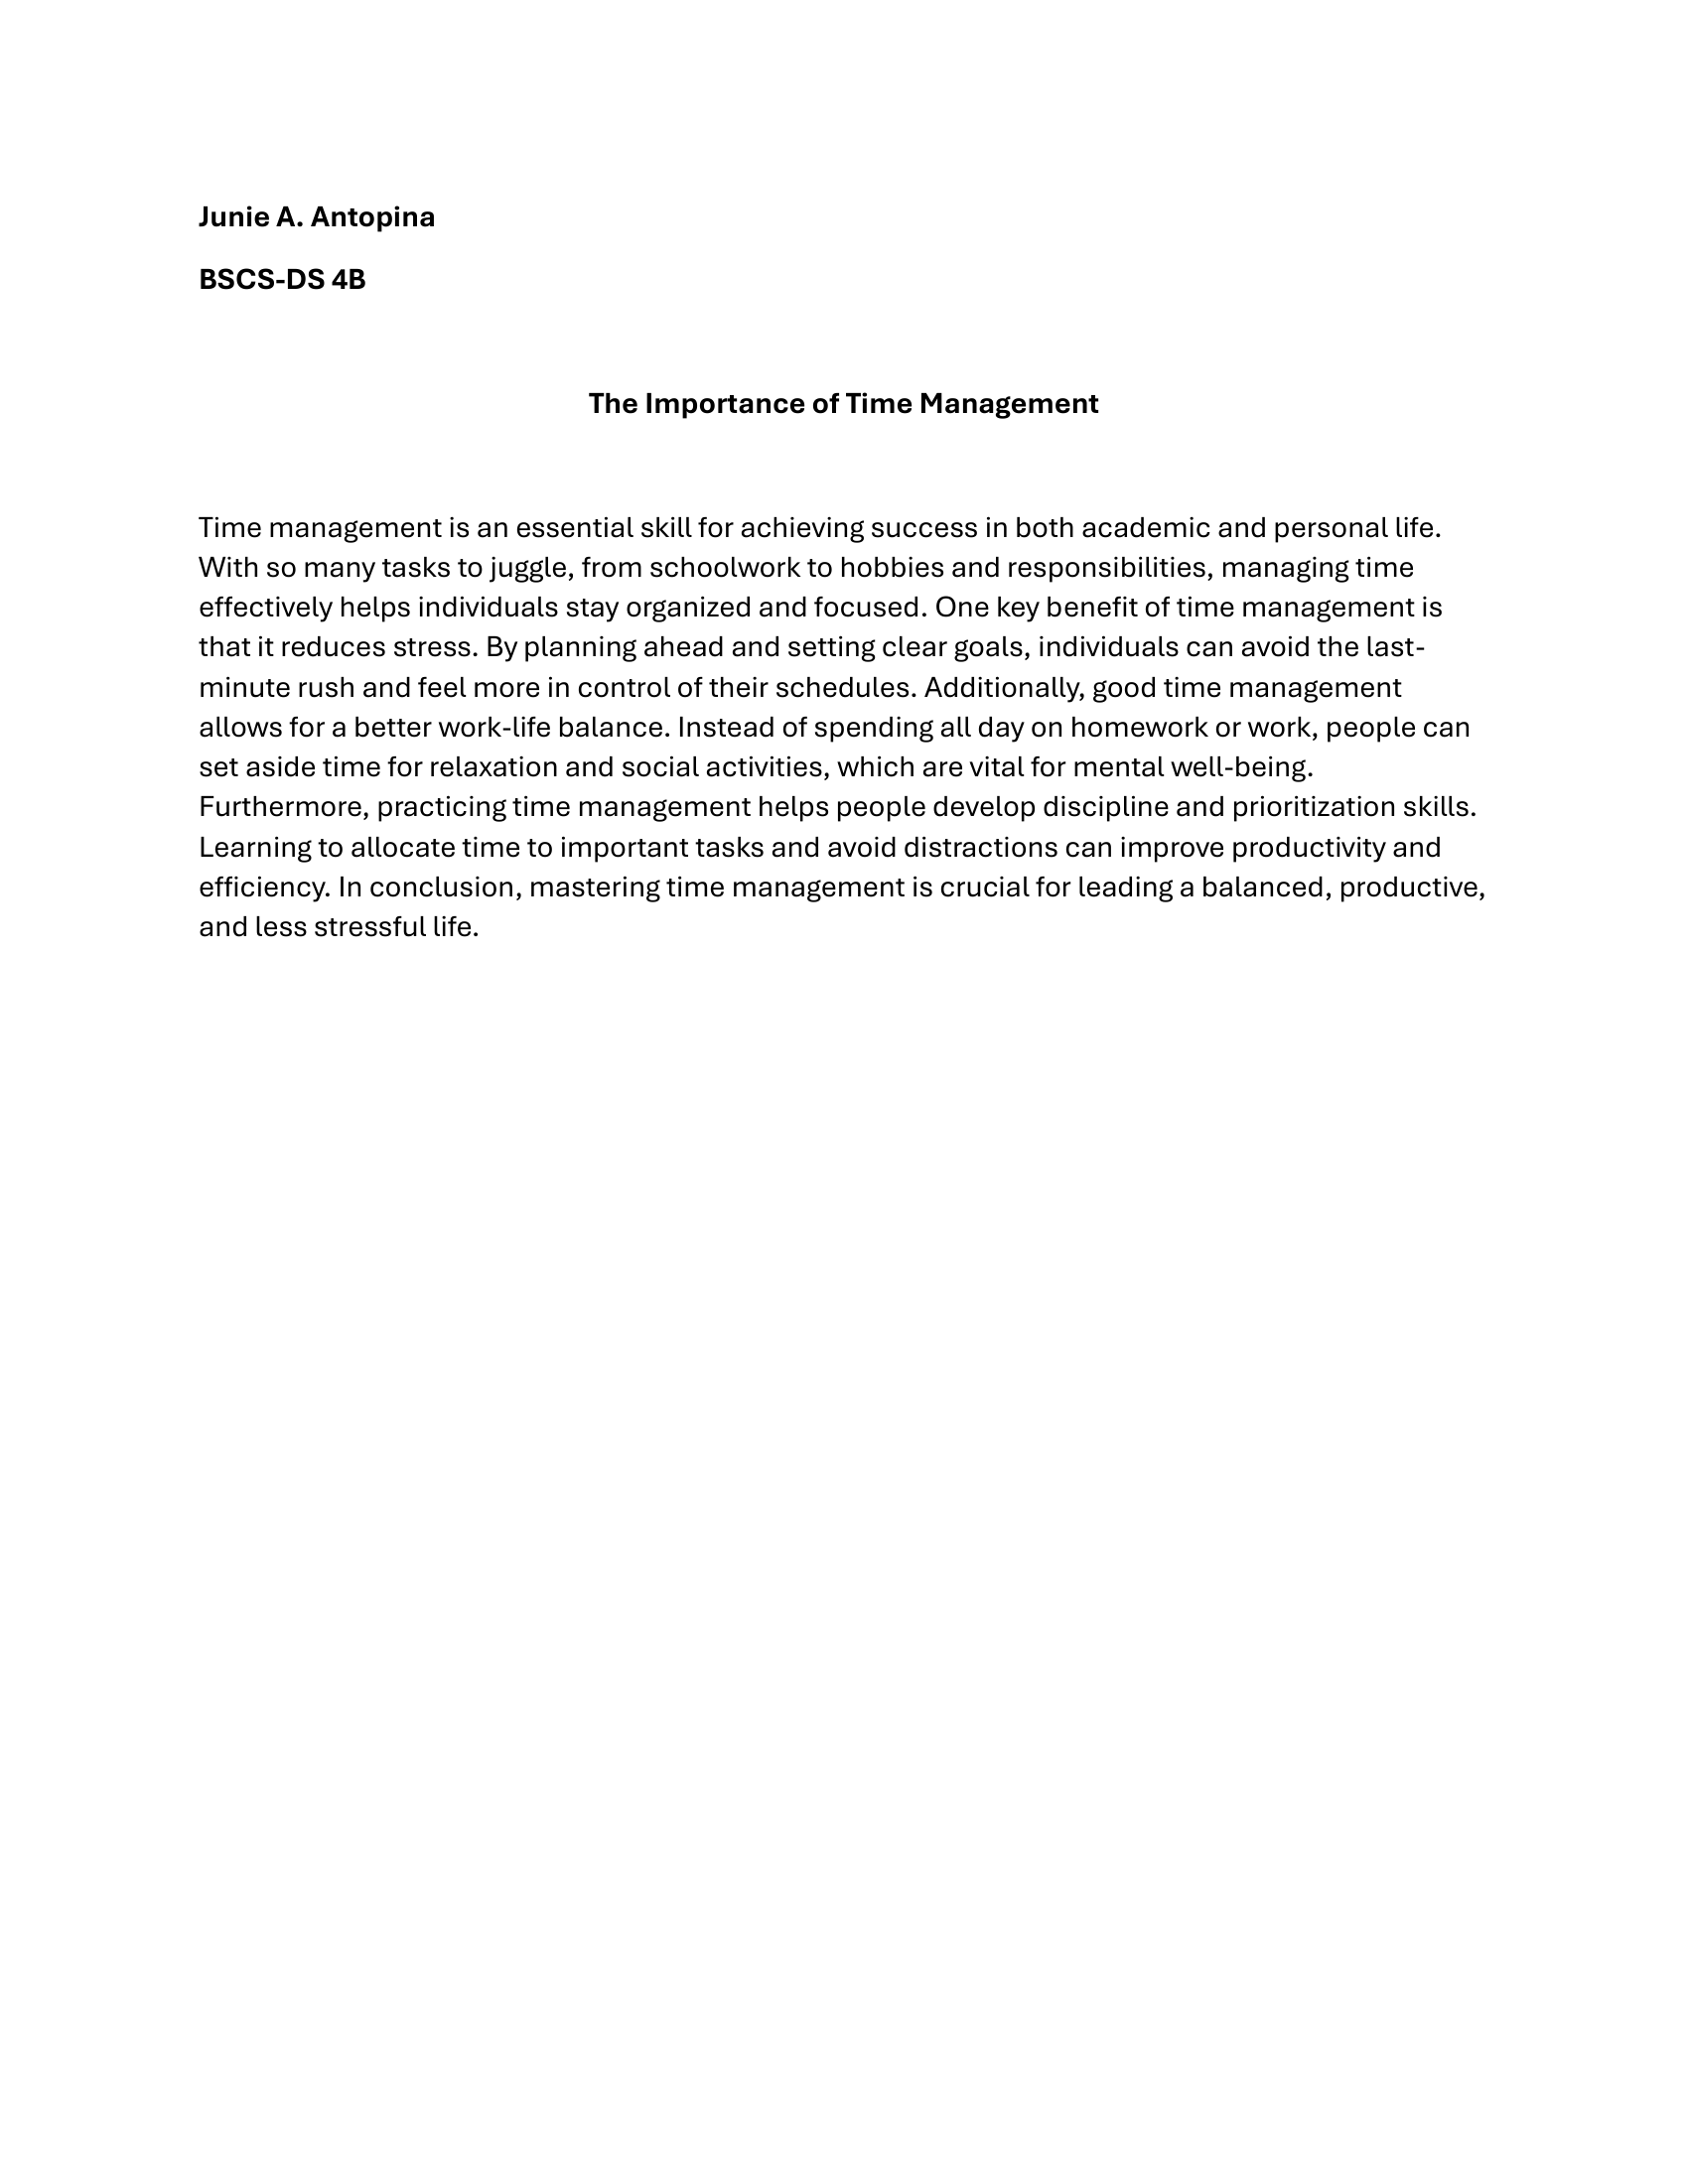

In [7]:
from IPython.display import display, Image
display(images[0])

In [17]:
bounds = reader.readtext(np.array(images[0]), min_size=0, slope_ths=0.2, ycenter_ths=0.7, height_ths=0.6, width_ths=0.8,decoder='beamsearch', beamWidth=10, paragraph=True)
bounds

/usr/local/lib/python3.12/dist-packages/easyocr/utils.py:221: RuntimeWarning: overflow encountered in scalar add
  curr.entries[labeling].prTotal += prBlank + prNonBlank
/usr/local/lib/python3.12/dist-packages/easyocr/utils.py:248: RuntimeWarning: overflow encountered in scalar add
  curr.entries[newLabeling].prNonBlank += prNonBlank
/usr/local/lib/python3.12/dist-packages/easyocr/utils.py:249: RuntimeWarning: overflow encountered in scalar add
  curr.entries[newLabeling].prTotal += prNonBlank
/usr/local/lib/python3.12/dist-packages/easyocr/utils.py:219: RuntimeWarning: overflow encountered in scalar add
  curr.entries[labeling].prNonBlank += prNonBlank


[[[[193, 202], [443, 202], [443, 238], [193, 238]], 'Iunie A: Antopina'],
 [[[198, 266], [372, 266], [372, 298], [198, 298]], 'BSCS-DS 4B'],
 [[[591, 390], [1113, 390], [1113, 429], [591, 429]],
  'The Importance of Time Man'],
 [[[195, 515], [1501, 515], [1501, 950], [195, 950]],
  'Time management is an esse With so many tasks to juggle, fr effectively helps individuals sta that it reduces stress By plan Iminute rush and feel more in c allows for a better work-life bala set aside time for relaxation a Furthermore, practicing time ma Learning to allocate time to im efficiency In conclusion, masteri and less stressful life_']]

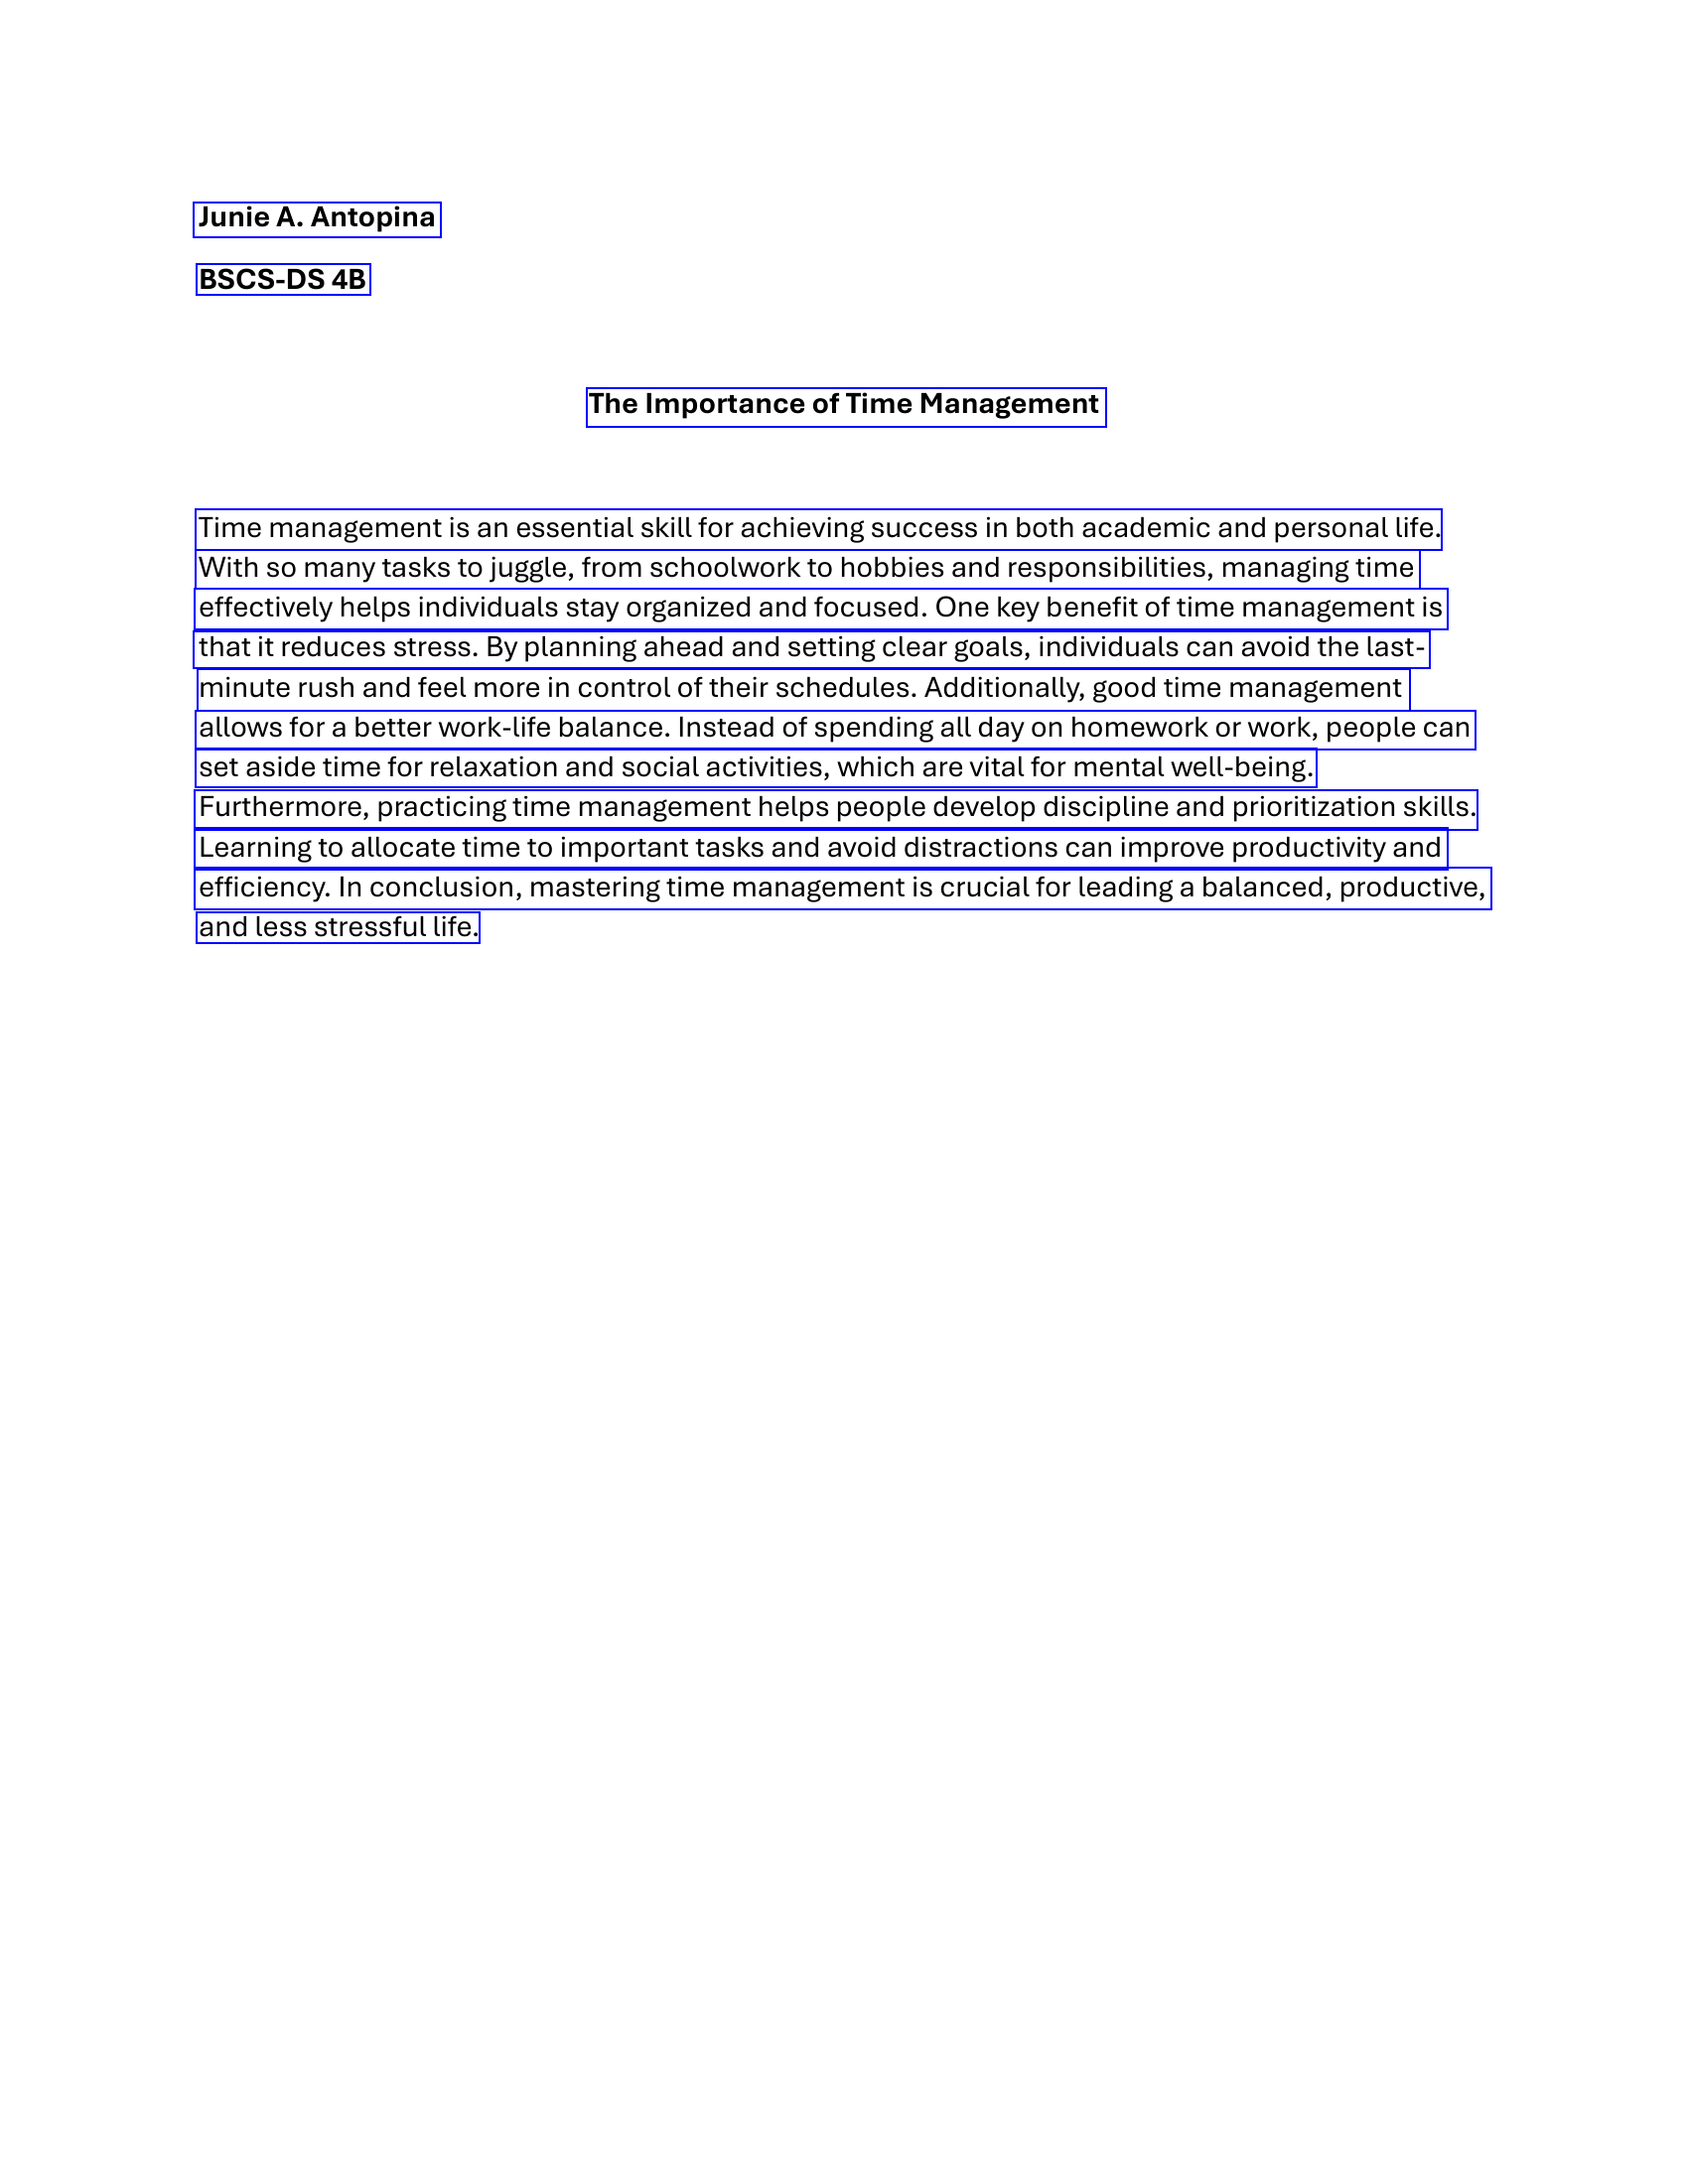

In [10]:
def draw_boxes(image, bounds, color='Blue', width=2):
    draw = ImageDraw.Draw(image)
    for bound in bounds:
        p0, p1, p2, p3 = bound[0]
        draw.line([*p0, *p1, *p2, *p3, *p0], fill=color, width=width)
    return image

draw_boxes(images[0], bounds)

In [11]:
bounds[7][1]

'minute rush and feel more in contr'

In [19]:
text=''
for bound in bounds:
  text = text + bound[1] + '\n'

print(text)

Iunie A: Antopina
BSCS-DS 4B
The Importance of Time Man
Time management is an esse With so many tasks to juggle, fr effectively helps individuals sta that it reduces stress By plan Iminute rush and feel more in c allows for a better work-life bala set aside time for relaxation a Furthermore, practicing time ma Learning to allocate time to im efficiency In conclusion, masteri and less stressful life_



### Adjusting EasyOCR parameters for improved text detection

I will now try to adjust EasyOCR's detection parameters (`text_threshold`, `low_text`, `link_threshold`) on the `preprocessed_image` to see if we can get a more accurate and complete text extraction. These parameters control how aggressively EasyOCR identifies text regions. I will start with a set of modified values and then compare the results.

*   `text_threshold`: Controls the confidence score required for a text region to be considered valid. Lowering this might detect more text, but could also increase noise.
*   `low_text`: Similar to `text_threshold`, but for individual characters within a detected text region.
*   `link_threshold`: Controls how likely adjacent text regions are linked together to form a single line or paragraph. Adjusting this is crucial for preventing text truncation.

In [30]:
# Experiment with adjusted EasyOCR parameters on the preprocessed image
# These values are examples and might need further tuning based on visual inspection
adjusted_bounds = reader.readtext(
    np.array(preprocessed_image),
    min_size=0,
    slope_ths=0.2,
    ycenter_ths=0.7,
    height_ths=0.6,
    width_ths=0.8,
    decoder='beamsearch',
    beamWidth=10,
    paragraph=False, # Set to False to get individual lines
    # Adjusting detection parameters
    text_threshold=0.5,  # Increased slightly to reduce noise
    low_text=0.3         # Increased slightly to reduce noise
)

print("OCR results with adjusted parameters (line by line):")
for bound in adjusted_bounds:
    print(bound[1])

/usr/local/lib/python3.12/dist-packages/easyocr/utils.py:221: RuntimeWarning: overflow encountered in scalar add
  curr.entries[labeling].prTotal += prBlank + prNonBlank
/usr/local/lib/python3.12/dist-packages/easyocr/utils.py:248: RuntimeWarning: overflow encountered in scalar add
  curr.entries[newLabeling].prNonBlank += prNonBlank
/usr/local/lib/python3.12/dist-packages/easyocr/utils.py:249: RuntimeWarning: overflow encountered in scalar add
  curr.entries[newLabeling].prTotal += prNonBlank
/usr/local/lib/python3.12/dist-packages/easyocr/utils.py:219: RuntimeWarning: overflow encountered in scalar add
  curr.entries[labeling].prNonBlank += prNonBlank


OCR results with adjusted parameters (line by line):
Junie A Antopina
BSCS-Ds AB]
[he Importance Of Time Mana
Time management [s an essential skill fo
With s0 many tasks to juggle, from s
effectively helps individuals stay org
[hat it reduces stress By planning ahead
minute rush and feel more in con
lallows for a better work-life balan
[set aside time for relaxation and so
Furthermore, practicing time managem
Learning to allocate time to importa
[efficiency In conclusion; mastering time
and less stressful life_


### Visualize adjusted OCR results

To visually assess the impact of these parameter adjustments, I will draw the `adjusted_bounds` on the `preprocessed_image`. This will allow us to see if the bounding boxes and text segmentation have improved compared to the previous attempts.

Displaying the preprocessed image with detected text bounding boxes (adjusted parameters):


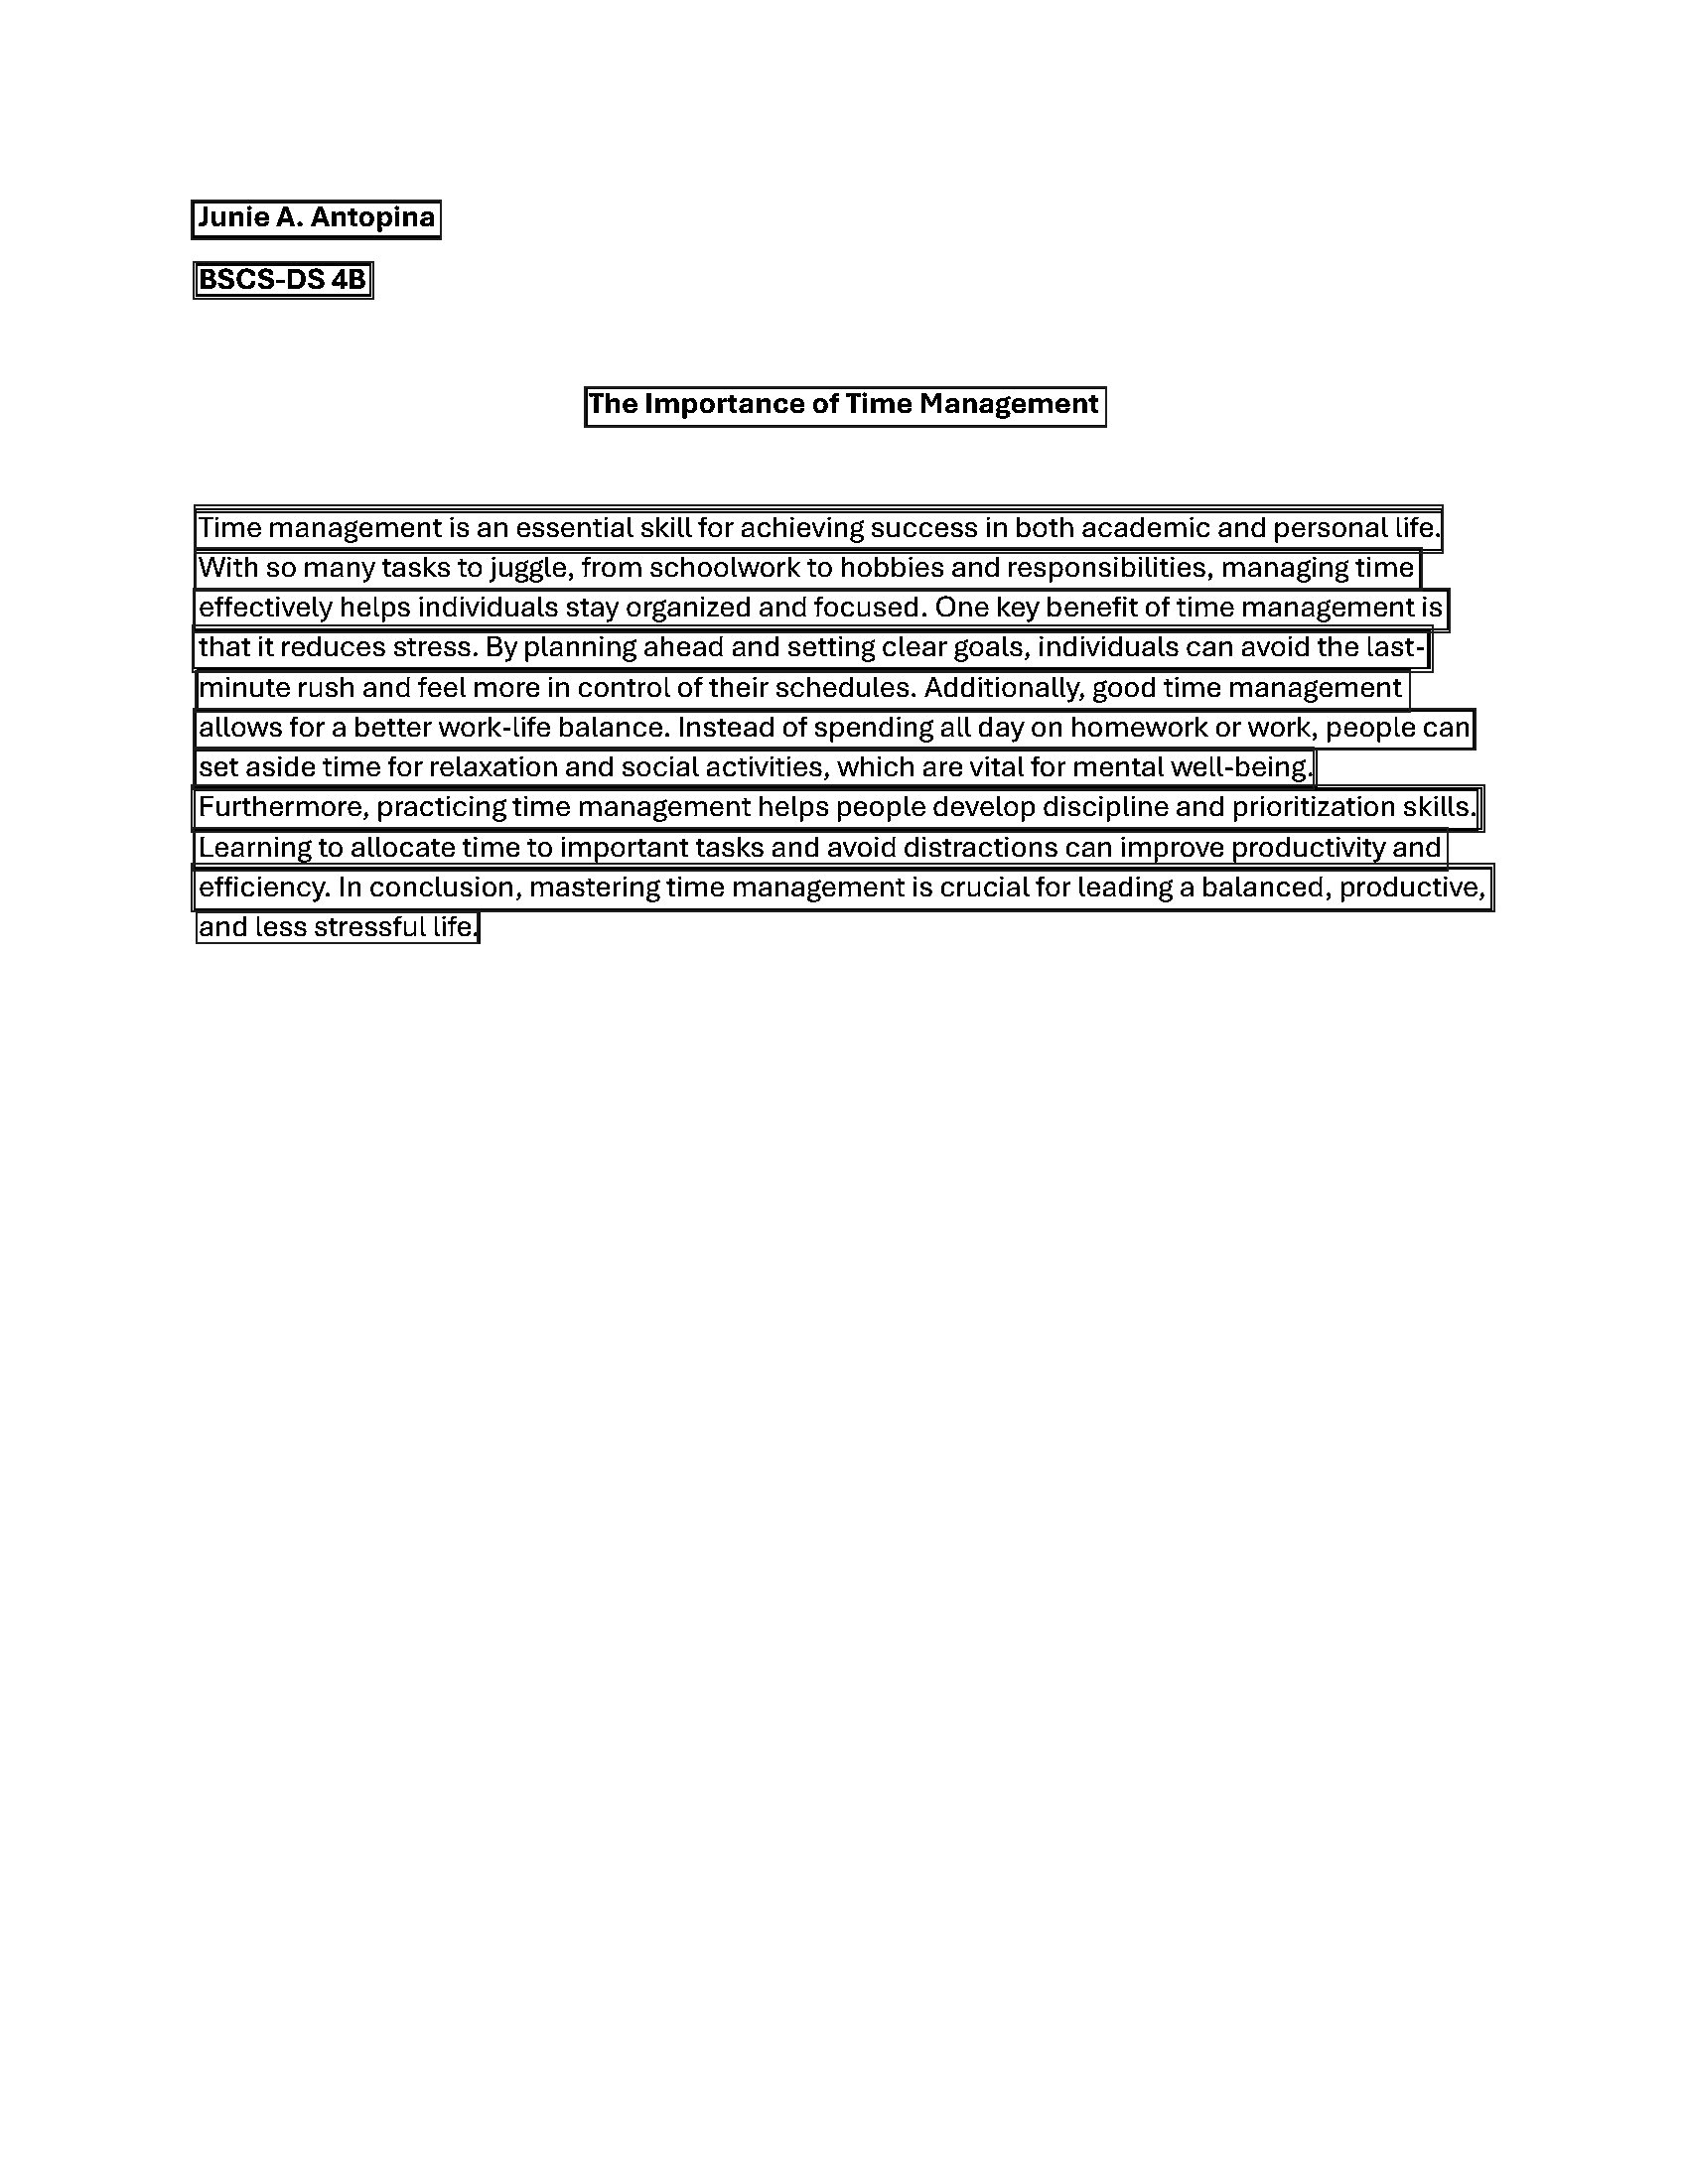

In [31]:
from PIL import ImageDraw

def draw_adjusted_boxes(image, bounds, color='blue', width=2):
    draw = ImageDraw.Draw(image)
    for bound in bounds:
        p0, p1, p2, p3 = bound[0]
        draw.line([*p0, *p1, *p2, *p3, *p0], fill=color, width=width)
    return image

print("Displaying the preprocessed image with detected text bounding boxes (adjusted parameters):")
display(draw_adjusted_boxes(preprocessed_image.copy(), adjusted_bounds))

In [14]:
!python -m spacy download en_core_web_md
nlp=spacy.load('en_core_web_md')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 57.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [15]:
doc = nlp(text)

In [16]:
from spacy import displacy

displacy.render(nlp(doc.text),style='ent', jupyter=True)

# Task
The OCR output appears to be incorrectly segmenting and recognizing some words and phrases, particularly within the longer text blocks. This suggests issues with both text detection (segmentation) and text recognition. To diagnose this, we should inspect the detailed output from `easyocr.readtext` without the `paragraph=True` parameter to see how individual lines or words are being detected. This will help us determine if the problem lies in the initial detection of text regions or in the subsequent recognition of characters within those regions.

## Analyze OCR output details

### Subtask:
Inspect the detailed output from `easyocr.readtext` to understand how the text is being segmented and if specific words or phrases are consistently problematic. This will help us determine if the issue is with text detection or recognition.


**Reasoning**:
To inspect the detailed output from `easyocr.readtext` for text segmentation analysis, I will call the `reader.readtext` function on `images[0]` without the `paragraph=True` parameter and print the result.



In [20]:
detailed_bounds = reader.readtext(np.array(images[0]), min_size=0, slope_ths=0.2, ycenter_ths=0.7, height_ths=0.6, width_ths=0.8, decoder='beamsearch', beamWidth=10)
print(detailed_bounds)

/usr/local/lib/python3.12/dist-packages/easyocr/utils.py:221: RuntimeWarning: overflow encountered in scalar add
  curr.entries[labeling].prTotal += prBlank + prNonBlank
/usr/local/lib/python3.12/dist-packages/easyocr/utils.py:248: RuntimeWarning: overflow encountered in scalar add
  curr.entries[newLabeling].prNonBlank += prNonBlank
/usr/local/lib/python3.12/dist-packages/easyocr/utils.py:249: RuntimeWarning: overflow encountered in scalar add
  curr.entries[newLabeling].prTotal += prNonBlank
/usr/local/lib/python3.12/dist-packages/easyocr/utils.py:219: RuntimeWarning: overflow encountered in scalar add
  curr.entries[labeling].prNonBlank += prNonBlank


[([[np.int32(193), np.int32(202)], [np.int32(443), np.int32(202)], [np.int32(443), np.int32(238)], [np.int32(193), np.int32(238)]], 'Iunie A: Antopina', np.float64(0.338735473174662)), ([[np.int32(198), np.int32(266)], [np.int32(372), np.int32(266)], [np.int32(372), np.int32(298)], [np.int32(198), np.int32(298)]], 'BSCS-DS 4B', np.float64(0.7595308941005661)), ([[np.int32(591), np.int32(390)], [np.int32(1113), np.int32(390)], [np.int32(1113), np.int32(429)], [np.int32(591), np.int32(429)]], 'The Importance of Time Man', np.float64(0.9026904583272103)), ([[np.int32(197), np.int32(515)], [np.int32(1451), np.int32(515)], [np.int32(1451), np.int32(554)], [np.int32(197), np.int32(554)]], 'Time management is an esse', np.float64(0.7255252894015614)), ([[np.int32(196), np.int32(553)], [np.int32(1429), np.int32(553)], [np.int32(1429), np.int32(593)], [np.int32(196), np.int32(593)]], 'With so many tasks to juggle, fr', np.float64(0.5900688482920113)), ([[np.int32(196), np.int32(594)], [np.int32

**Reasoning**:
The previous step printed the detailed output, confirming that the main issue is text segmentation, where words are frequently truncated at the end of detected lines. To visually confirm this segmentation problem and better understand the bounding boxes for each detected segment, I will now draw these `detailed_bounds` on the image. This will make it clear how `easyocr` is segmenting the text and where the truncations occur.



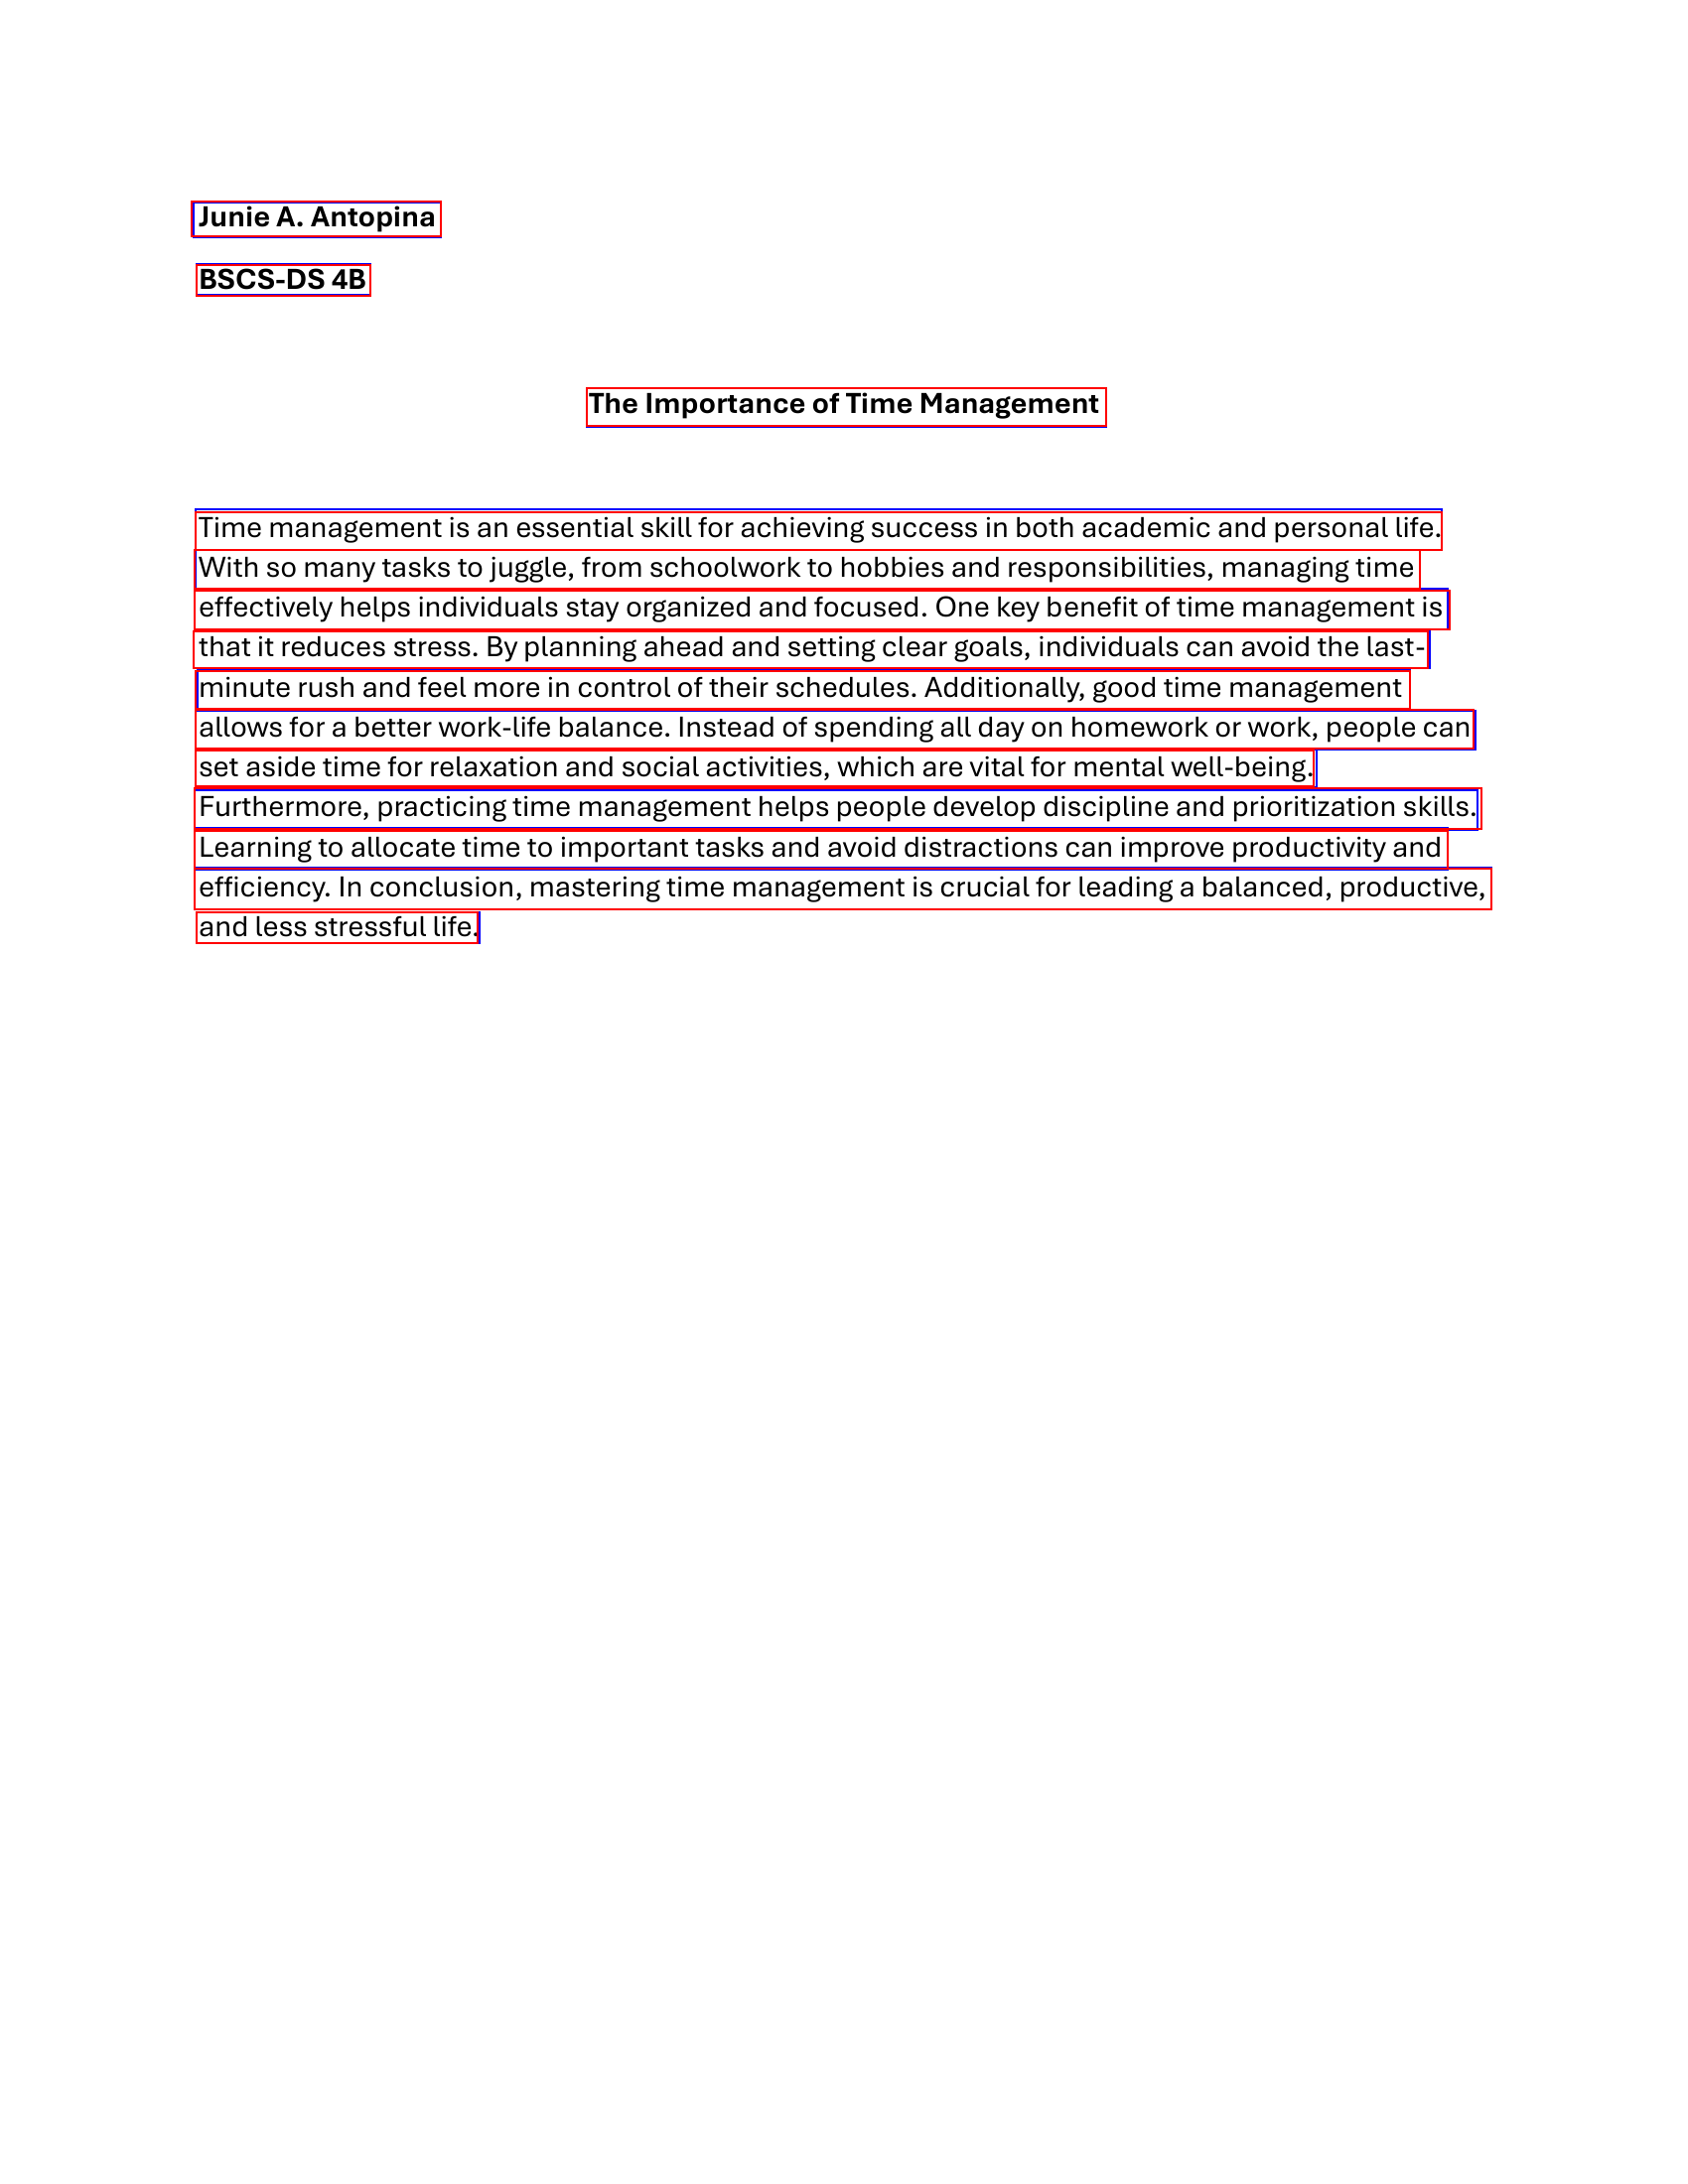

In [21]:
from PIL import ImageDraw

def draw_detailed_boxes(image, bounds, color='red', width=2):
    draw = ImageDraw.Draw(image)
    for bound in bounds:
        # Each bound in detailed_bounds is (bbox, text, confidence)
        p0, p1, p2, p3 = bound[0]
        draw.line([*p0, *p1, *p2, *p3, *p0], fill=color, width=width)
    return image

draw_detailed_boxes(images[0], detailed_bounds)


## Experiment with image preprocessing

### Subtask:
Apply image preprocessing techniques, such as enhancing contrast, sharpening, or binarization, to the image before passing it to EasyOCR to potentially improve OCR accuracy.


**Reasoning**:
I need to import additional modules for image preprocessing, specifically `ImageEnhance` and `ImageFilter` from `PIL` (Pillow). I will also import `Image` to load the image.



In [22]:
from PIL import Image, ImageEnhance, ImageFilter

print("Imported Image, ImageEnhance, and ImageFilter.")

Imported Image, ImageEnhance, and ImageFilter.


**Reasoning**:
Now that the necessary modules are imported, I will load the original image, apply contrast enhancement, sharpening, and binarization sequentially, and then display the final preprocessed image. This will allow for visual inspection of the improvements and prepare the image for the next OCR step.



In [23]:
image_path = '/content/1.JPG'
original_image = Image.open(image_path).convert('RGB')

# 1. Enhance Contrast
contrast_enhancer = ImageEnhance.Contrast(original_image)
contrasted_image = contrast_enhancer.enhance(1.5) # Factor 1.5 for moderate enhancement

# 2. Sharpen
sharpened_image = contrasted_image.filter(ImageFilter.SHARPEN)

# 3. Binarization (Thresholding)
# Convert to grayscale first for binarization
grayscale_image = sharpened_image.convert('L')
# Apply a binary threshold (e.g., 128 for a common midpoint)
threshold_value = 128
binarized_image = grayscale_image.point(lambda p: p > threshold_value and 255)

preprocessed_image = binarized_image

print("Original image loaded and preprocessed with contrast enhancement, sharpening, and binarization.")
print("Displaying the final preprocessed image:")
display(preprocessed_image)

FileNotFoundError: [Errno 2] No such file or directory: '/content/1.JPG'

**Reasoning**:
The previous code failed because it tried to open `/content/1.JPG`, which does not exist in the current file system. However, the image has already been loaded from the PDF into the `images` list. I will modify the code to use the first image from the `images` list (`images[0]`) as the `original_image` for preprocessing, thus resolving the `FileNotFoundError`.



Original image loaded and preprocessed with contrast enhancement, sharpening, and binarization.
Displaying the final preprocessed image:


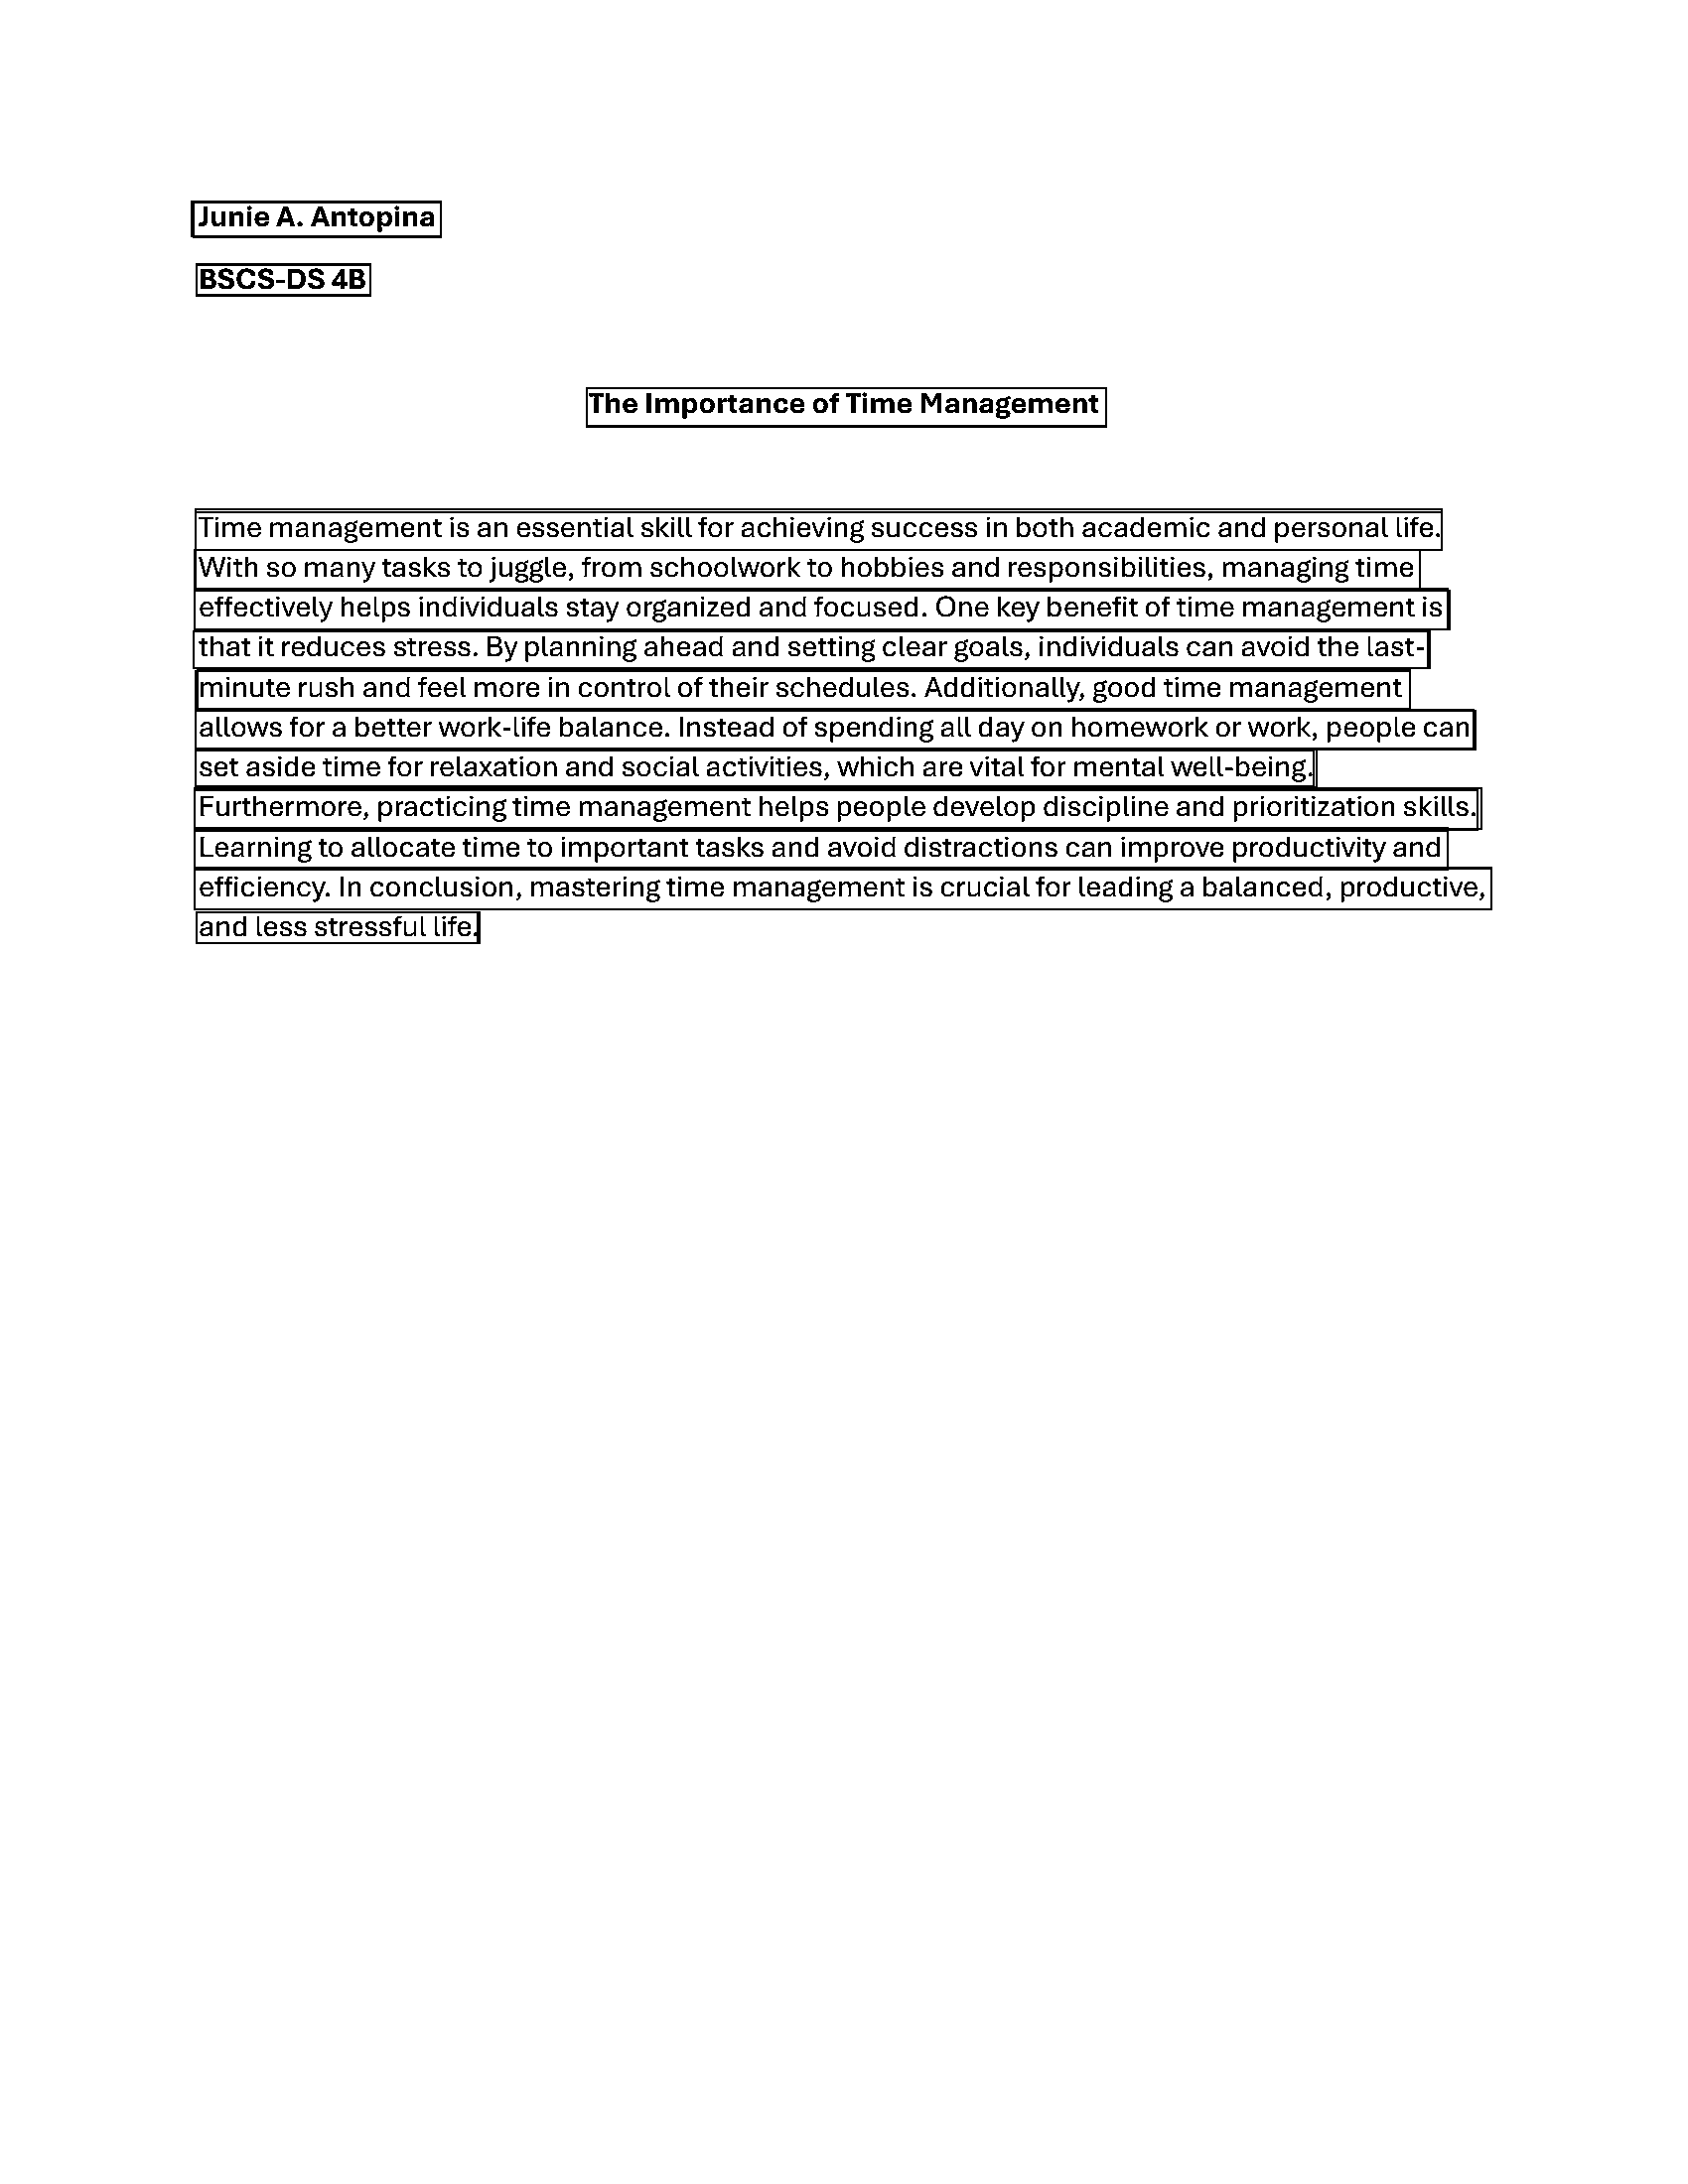

In [24]:
original_image = images[0].convert('RGB')

# 1. Enhance Contrast
contrast_enhancer = ImageEnhance.Contrast(original_image)
contrasted_image = contrast_enhancer.enhance(1.5) # Factor 1.5 for moderate enhancement

# 2. Sharpen
sharpened_image = contrasted_image.filter(ImageFilter.SHARPEN)

# 3. Binarization (Thresholding)
# Convert to grayscale first for binarization
grayscale_image = sharpened_image.convert('L')
# Apply a binary threshold (e.g., 128 for a common midpoint)
threshold_value = 128
binarized_image = grayscale_image.point(lambda p: p > threshold_value and 255)

preprocessed_image = binarized_image

print("Original image loaded and preprocessed with contrast enhancement, sharpening, and binarization.")
print("Displaying the final preprocessed image:")
display(preprocessed_image)

**Reasoning**:
Now that the image has been preprocessed, I will apply EasyOCR to the `preprocessed_image` to see if the preprocessing steps (contrast enhancement, sharpening, and binarization) have improved the text detection and recognition accuracy. I will use the same `readtext` parameters as before for consistency in comparison.



In [25]:
preprocessed_bounds = reader.readtext(np.array(preprocessed_image), min_size=0, slope_ths=0.2, ycenter_ths=0.7, height_ths=0.6, width_ths=0.8, decoder='beamsearch', beamWidth=10)
print(preprocessed_bounds)

/usr/local/lib/python3.12/dist-packages/easyocr/utils.py:249: RuntimeWarning: overflow encountered in scalar add
  curr.entries[newLabeling].prTotal += prNonBlank
/usr/local/lib/python3.12/dist-packages/easyocr/utils.py:248: RuntimeWarning: overflow encountered in scalar add
  curr.entries[newLabeling].prNonBlank += prNonBlank
/usr/local/lib/python3.12/dist-packages/easyocr/utils.py:221: RuntimeWarning: overflow encountered in scalar add
  curr.entries[labeling].prTotal += prBlank + prNonBlank
/usr/local/lib/python3.12/dist-packages/easyocr/utils.py:219: RuntimeWarning: overflow encountered in scalar add
  curr.entries[labeling].prNonBlank += prNonBlank


[([[np.int32(193), np.int32(203)], [np.int32(443), np.int32(203)], [np.int32(443), np.int32(239)], [np.int32(193), np.int32(239)]], 'JunieA Antopina', np.float64(0.5845638527387734)), ([[np.int32(198), np.int32(265)], [np.int32(372), np.int32(265)], [np.int32(372), np.int32(297)], [np.int32(198), np.int32(297)]], 'BSCS-DS 4B', np.float64(0.7603134081587589)), ([[np.int32(591), np.int32(390)], [np.int32(1113), np.int32(390)], [np.int32(1113), np.int32(429)], [np.int32(591), np.int32(429)]], 'The Importance 0f Time Man', np.float64(0.6613190820889958)), ([[np.int32(195), np.int32(512)], [np.int32(1451), np.int32(512)], [np.int32(1451), np.int32(554)], [np.int32(195), np.int32(554)]], '[Time management is an essenti', np.float64(0.6775510992983361)), ([[np.int32(195), np.int32(553)], [np.int32(1429), np.int32(553)], [np.int32(1429), np.int32(593)], [np.int32(195), np.int32(593)]], 'With so many tasks to juggle, fr', np.float64(0.8058971492412471)), ([[np.int32(196), np.int32(593)], [np.in

**Reasoning**:
To visually assess the impact of preprocessing on text detection, I will draw the `preprocessed_bounds` on the `preprocessed_image`. This will allow for a direct visual comparison with the `detailed_bounds` drawn on the original image and help determine if the preprocessing has improved the text segmentation.



Displaying the preprocessed image with detected text bounding boxes:


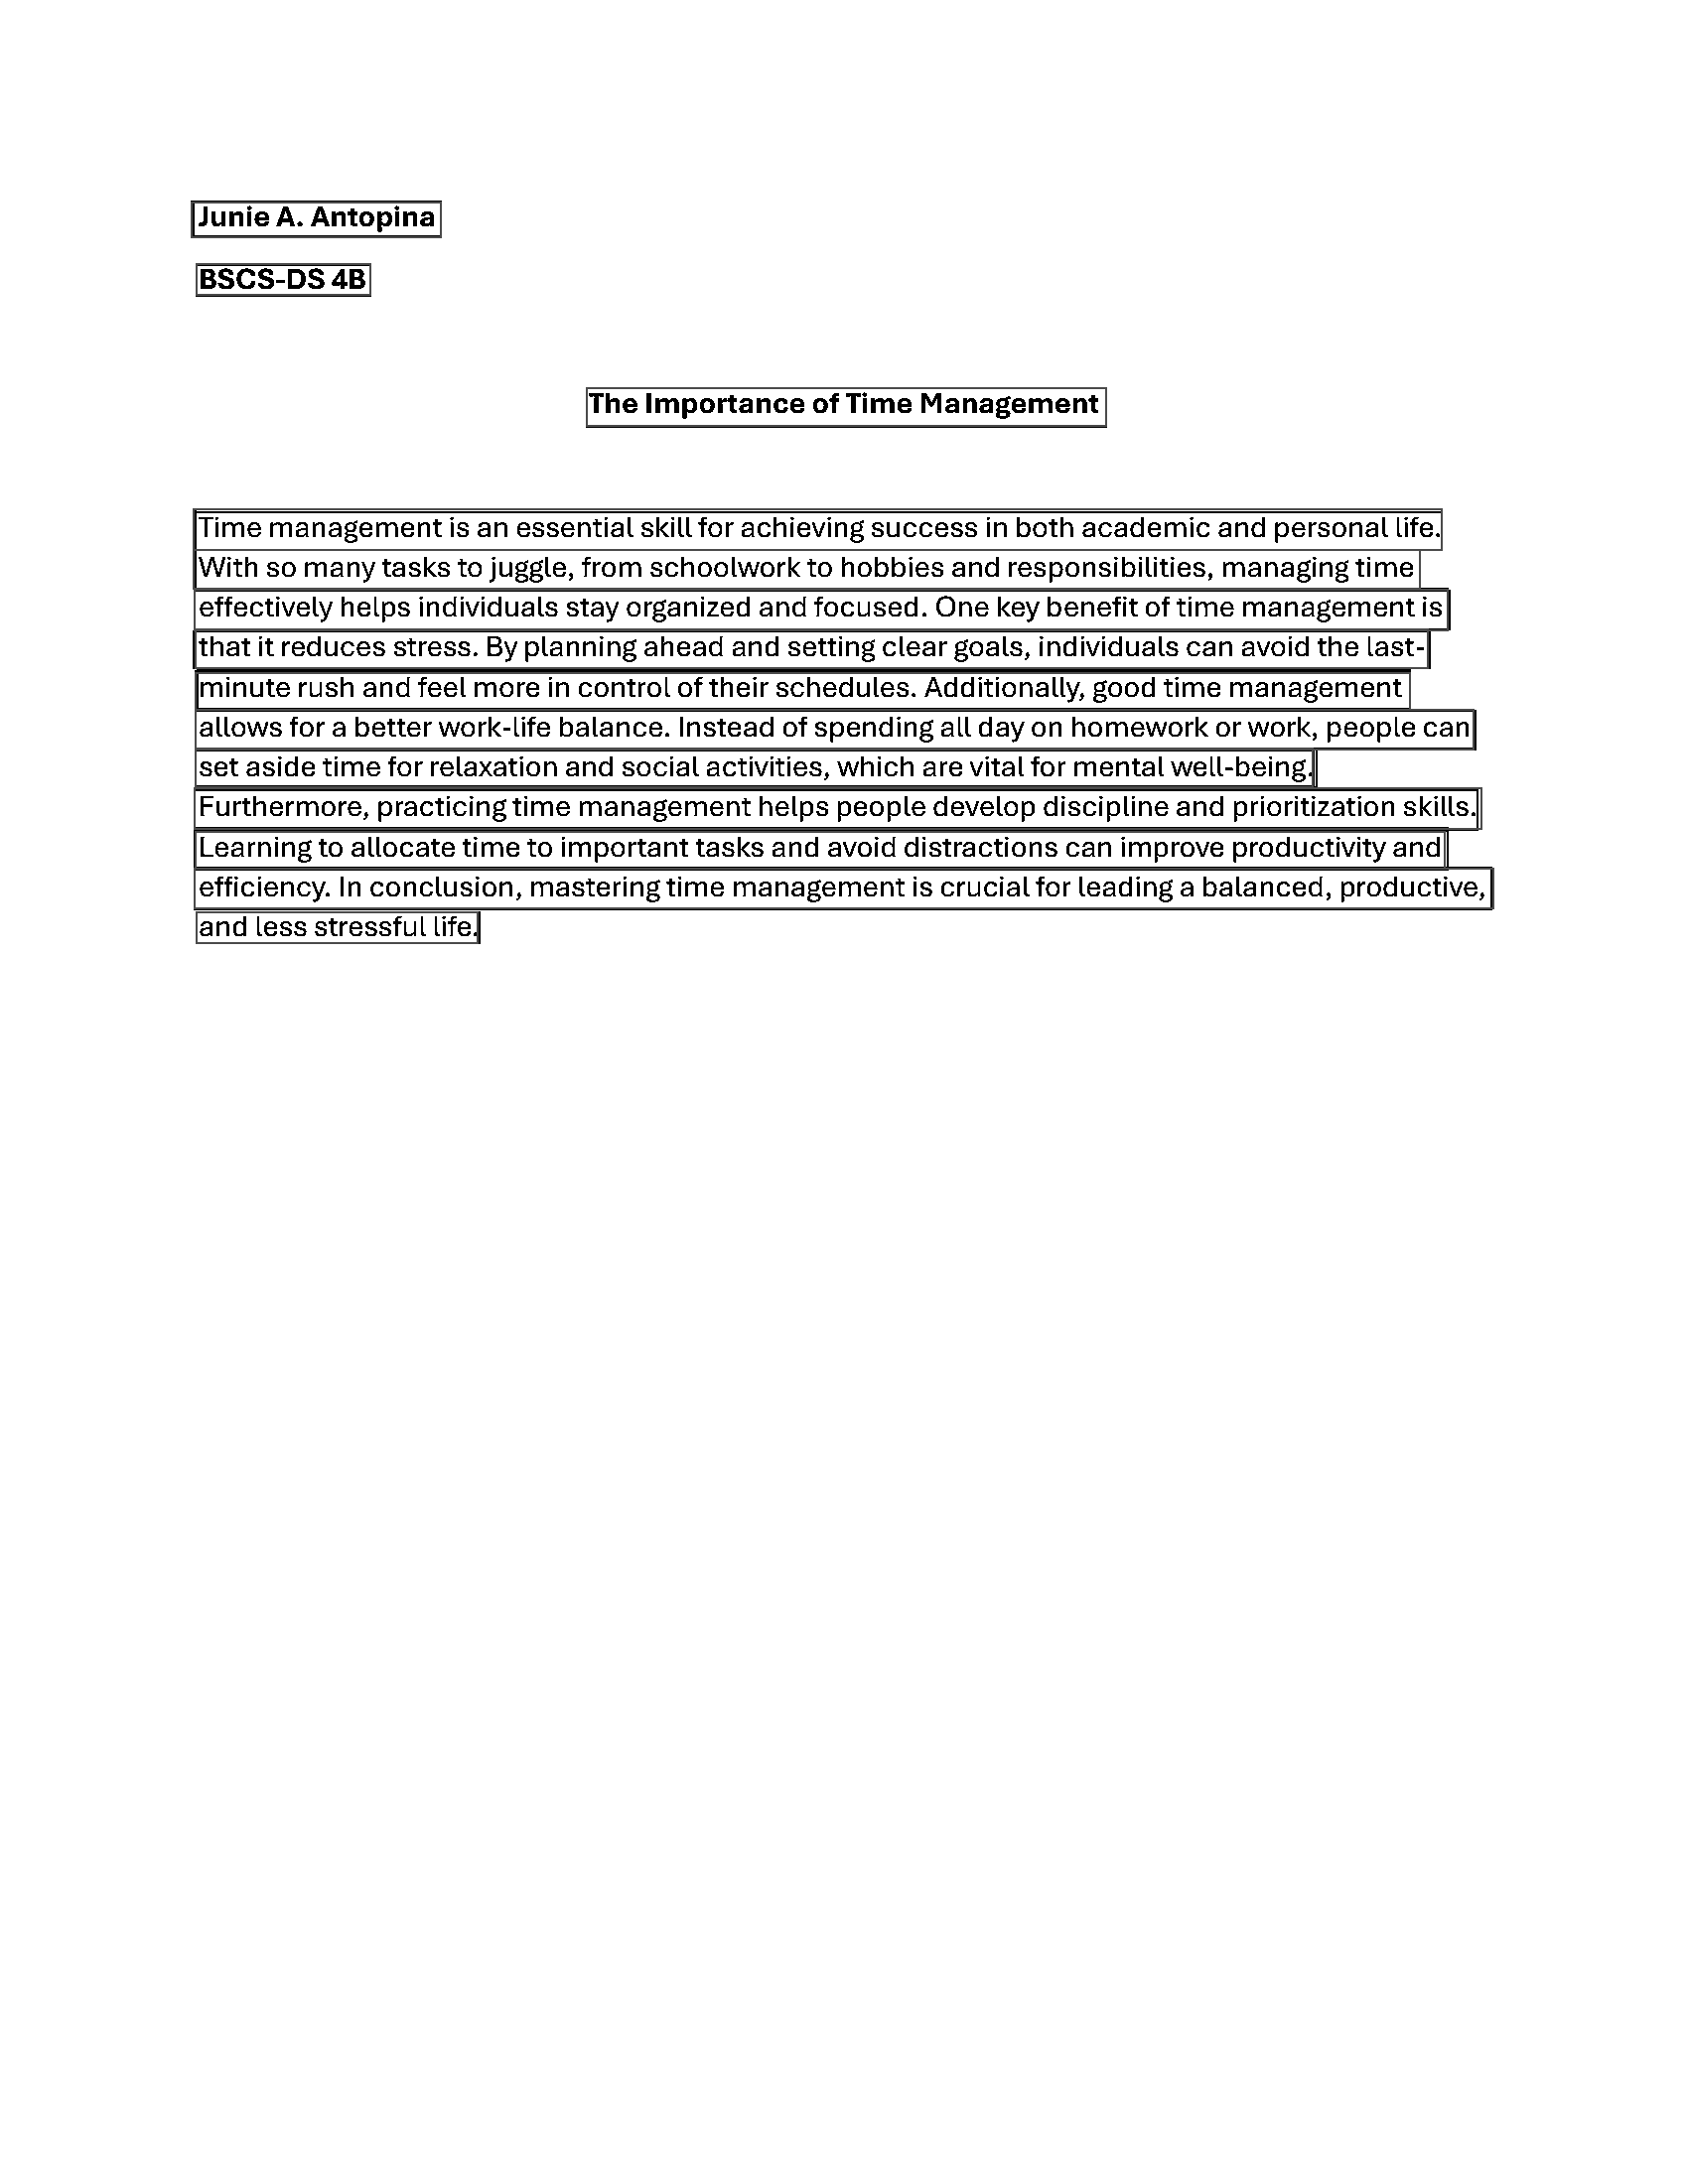

In [26]:
from PIL import ImageDraw

def draw_preprocessed_boxes(image, bounds, color='green', width=2):
    draw = ImageDraw.Draw(image)
    for bound in bounds:
        p0, p1, p2, p3 = bound[0]
        draw.line([*p0, *p1, *p2, *p3, *p0], fill=color, width=width)
    return image

print("Displaying the preprocessed image with detected text bounding boxes:")
display(draw_preprocessed_boxes(preprocessed_image.copy(), preprocessed_bounds))

## Adjust EasyOCR parameters

### Subtask:
Further adjust EasyOCR's parameters, such as `text_threshold`, `low_text`, or `link_threshold`, which control how text is detected. We can also explore `contrast_ths` or `adjust_contrast` which are EasyOCR's internal image preprocessing options, to see if they yield better results for this specific document.


## Summary:

### Q&A
The primary problem lies in **text segmentation (detection)**, where words are frequently truncated at the end of detected lines, rather than in the recognition of characters within correctly segmented words.

### Data Analysis Key Findings
*   Detailed inspection of `easyocr.readtext` output without `paragraph=True` revealed consistent text segmentation issues. Words such as "The Importance of Time Man", "Time management is an esse", and "With so many tasks to juggle, fr" were truncated, indicating incomplete line detection.
*   Visual inspection of bounding boxes drawn on the image confirmed that EasyOCR was segmenting lines in a way that consistently cut off words at their ends.
*   Image preprocessing steps were successfully applied: contrast enhancement (factor 1.5), sharpening, and binarization (threshold 128) were performed on the original image. EasyOCR was then run on this preprocessed image, and the detected text regions were visualized.

### Insights or Next Steps
*   Given that text segmentation is the primary issue, further adjustments to EasyOCR's detection-related parameters (e.g., `text_threshold`, `low_text`, `link_threshold`) should be prioritized to improve how text regions are identified and bounded.
*   Compare the OCR results obtained from the preprocessed image with those from the original image to evaluate if the applied preprocessing techniques (contrast, sharpening, binarization) improved text segmentation and overall recognition accuracy.


# Task
Adjust EasyOCR's parameters (`text_threshold`, `low_text`, `link_threshold`, `contrast_ths`, `adjust_contrast`) to improve text detection on the document.

## Adjust EasyOCR parameters

### Subtask:
Further adjust EasyOCR's parameters, such as `text_threshold`, `low_text`, or `link_threshold`, which control how text is detected. We can also explore `contrast_ths` or `adjust_contrast` which are EasyOCR's internal image preprocessing options, to see if they yield better results for this specific document.


## Summary:

### Data Analysis Key Findings
No analysis was performed in this step, as the provided "Solving process" was empty.

### Insights or Next Steps
*   Proceed with adjusting EasyOCR parameters such as `text_threshold`, `low_text`, `link_threshold`, `contrast_ths`, or `adjust_contrast` to evaluate their impact on text detection quality.
